# Static Graph Representation and Architecture Study

## CAMELS-SIMBA U1000 / Top1500 / $\Omega_m$ Regression

**Notebook 15 — final static-study consolidation.** This notebook asks how graph construction and static GNN architecture affect inference of $\Omega_m$ from final-snapshot halo catalogues. It reconstructs every displayed statistic from frozen registry records and stored predictions; it performs **no training, tuning, graph building, dataset building, or inference**.

The experiments were performed sequentially. Decisions were frozen on validation evidence before held-out test values were inspected; test results are shown only as post-freeze confirmation. The narrative therefore preserves the actual experimental chronology rather than selecting retrospectively on test performance.

# 1 — Reproducibility and artifact preflight

The preflight resolves the repository from the notebook location, checks the expected source commit, verifies every critical registry/report/run artifact, and confirms prediction row counts and seed identities. Historical experiment outputs may be untracked; existence and integrity—not Git tracking status—are the relevant requirements.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import json, math, subprocess, warnings

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

warnings.filterwarnings('ignore', category=FutureWarning)

def find_repo_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / '.git').exists() and (candidate / 'experiments').is_dir():
            return candidate
    raise RuntimeError('Repository root could not be resolved.')

ROOT = find_repo_root()
OUT = ROOT / 'notebooks/visualization/outputs/15_u1000_static_graph_representation_and_architecture_study'
OUT.mkdir(parents=True, exist_ok=True)
SEEDS = [42, 123, 2025]
KS = [4, 6, 8, 12]
COUNTS = {'train': 700, 'val': 99, 'test': 201}
EXPECTED_START_HEAD = 'c5ddebac3c66aa0e95ec8801d5ddcd3812d35240'
HEAD = subprocess.run(['git', 'rev-parse', 'HEAD'], cwd=ROOT, check=True, capture_output=True, text=True).stdout.strip()
BRANCH = subprocess.run(['git', 'branch', '--show-current'], cwd=ROOT, check=True, capture_output=True, text=True).stdout.strip()
start_is_ancestor = subprocess.run(['git','merge-base','--is-ancestor',EXPECTED_START_HEAD,HEAD], cwd=ROOT).returncode == 0
assert start_is_ancestor, f'Required starting commit {EXPECTED_START_HEAD} is not an ancestor of {HEAD}'
assert BRANCH == 'thesis-notebook15-graph-representation'

COLORS = {'Static GCN': '#76B7B2', 'Radius Static GCN': '#F28E2B', 'Static PNA': '#E15759', 'frozen': '#4C78A8'}
SEED_COLORS = {42: '#4C78A8', 123: '#F28E2B', 2025: '#59A14F'}
plt.rcParams.update({'figure.dpi': 115, 'savefig.dpi': 240, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9.5, 'axes.titleweight': 'semibold'})

def load_json(path):
    return json.loads(path.read_text())

def savefig(fig, name):
    path = OUT / name
    fig.savefig(path, dpi=240, bbox_inches='tight', transparent=True)
    plt.show()
    return path

def save_table(frame, number, slug):
    path = OUT / f'table{number:02d}_{slug}.csv'
    frame.to_csv(path, index=False)
    return frame

def metrics_from_predictions(frame):
    truth = frame.true_omega_m.to_numpy(float)
    pred = frame.pred_omega_m.to_numpy(float)
    residual = pred - truth
    mse = float(np.mean(residual**2))
    slope, intercept = np.polyfit(truth, pred, 1)
    return {'n': len(frame), 'mae': float(np.mean(np.abs(residual))), 'rmse': math.sqrt(mse),
            'r2': 1 - float(np.sum(residual**2)) / float(np.sum((truth-truth.mean())**2)),
            'sd_ratio': float(np.std(pred, ddof=1)/np.std(truth, ddof=1)),
            'slope': float(slope), 'intercept': float(intercept)}

REG = ROOT / 'reports/experiment_registry'
registry_files = [
    'u1000_top1500_knn_k_selection_freeze.json',
    'u1000_top1500_knn_postfreeze_test_evaluation.md',
    'u1000_top1500_radius_selection_freeze.json',
    'u1000_top1500_graph_representation_selection_freeze.json',
    'u1000_top1500_graph_representation_postfreeze_test_evaluation.md',
    'u1000_top1500_knn_k8_symmetry_protocol.json',
    'u1000_top1500_knn_k8_symmetry_full_evaluation.md',
    'u1000_top1500_static_pna_protocol.json',
    'u1000_top1500_static_gcn_vs_pna_architecture_freeze.json',
    'u1000_top1500_static_gcn_vs_pna_postfreeze_test_evaluation.md',
]
for name in registry_files:
    p = REG / name
    assert p.is_file() and p.stat().st_size > 0, f'Missing/empty registry artifact: {p}'

def run_name(kind, seed, k=None):
    if kind == 'gcn': return f'static_gcn_u1000_top1500_sparse_train700_seed{seed}_none_h32_l3_mean_mlp_final'
    if kind == 'knn': return f'static_gcn_u1000_top1500_knn_k{k}_sparse_train700_seed{seed}_none_h32_l3_mean_mlp_final'
    if kind == 'radius': return f'static_gcn_u1000_top1500_radius_r1p962822_sparse_train700_seed{seed}_none_h32_l3_mean_mlp_final'
    if kind == 'pna': return f'static_pna_u1000_top1500_sparse_train700_seed{seed}_none_h32_l3_mean_mlp_final'
    raise KeyError(kind)

required_runs = [run_name('gcn', s) for s in SEEDS] + [run_name('pna', s) for s in SEEDS] + \
                [run_name('radius', s) for s in SEEDS] + [run_name('knn', s, k) for k in [4,6,12] for s in SEEDS]
for name in required_runs:
    run = ROOT / 'experiments' / name
    for rel in ['config.json','metrics.json','train_log.csv','predictions/val_predictions.csv','predictions/test_predictions.csv']:
        p = run / rel
        assert p.is_file() and p.stat().st_size > 0, f'Missing/empty run artifact: {p}'

sym_pred_path = ROOT/'reports/symmetry/u1000_top1500_knn_k8_static_gcn/full/symmetry_full_predictions.csv'
sym_summary_path = ROOT/'reports/symmetry/u1000_top1500_knn_k8_static_gcn/full/symmetry_full_summary.json'
assert sym_pred_path.is_file() and sym_summary_path.is_file()

knn_freeze = load_json(REG/'u1000_top1500_knn_k_selection_freeze.json')
radius_freeze = load_json(REG/'u1000_top1500_radius_selection_freeze.json')
graph_freeze = load_json(REG/'u1000_top1500_graph_representation_selection_freeze.json')
pna_freeze = load_json(REG/'u1000_top1500_static_gcn_vs_pna_architecture_freeze.json')
assert knn_freeze['seeds'] == SEEDS and knn_freeze['selected_k'] == 8
assert graph_freeze['seeds'] == SEEDS and graph_freeze['selected_representation'] == 'knn_k8'
assert pna_freeze['seeds'] == SEEDS and pna_freeze['validation_classification'] == 'ROBUST DEGRADATION'

preflight = pd.DataFrame([
    ['Git identity', 'PASS', f'{BRANCH} @ {HEAD[:12]}'],
    ['Registry / report sources', 'PASS', f'{len(registry_files)}/{len(registry_files)} present'],
    ['Frozen experiment runs', 'PASS', f'{len(required_runs)}/{len(required_runs)} complete source sets'],
    ['Symmetry sources', 'PASS', 'predictions + machine-readable summary present'],
    ['Training invoked', 'NO', 'artifact loading only'],
], columns=['Check','Status','Evidence'])
display(preflight)
print(f'ARTIFACT PREFLIGHT: PASS — {datetime.now(timezone.utc).isoformat()}')

,Check,Status,Evidence
0,Git identity,PASS,thesis-notebook15-graph-representation @ 374f2...
1,Registry / report sources,PASS,10/10 present
2,Frozen experiment runs,PASS,18/18 complete source sets
3,Symmetry sources,PASS,predictions + machine-readable summary present
4,Training invoked,NO,artifact loading only


ARTIFACT PREFLIGHT: PASS — 2026-09-03T04:10:40.748909+00:00


# 2 — Frozen experimental protocol

The regression sample is one simulated universe; its nodes are the 1,500 most massive final-snapshot halos. The Static GCN uses three width-32 GCN message-passing layers, mean graph pooling, and an MLP regression head (5,281 trainable parameters). Raw absolute position and velocity components are passed without normalization.

In [2]:
table01 = pd.DataFrame([
    ['Dataset', 'CAMELS-SIMBA'], ['Universe count', '1,000'], ['Node selection', 'Top1500 halos by mass'],
    ['Snapshot', 'Final ($a=1$)'], ['Features', r'raw7: log10(Mvir), X, Y, Z, VX, VY, VZ'],
    ['Normalization', 'None'], ['Periodic box', r'25 $h^{-1}$ Mpc'],
    ['Final graph', 'Periodic sparse kNN'], ['Frozen k', '8'],
    ['Split', '700 train / 99 validation / 201 test'], ['Seeds', '42, 123, 2025'], ['Target', r'$\Omega_m$'],
], columns=['Setting','Value'])
save_table(table01, 1, 'frozen_static_protocol')
display(table01.style.hide(axis='index'))

Setting,Value
Dataset,CAMELS-SIMBA
Universe count,"1,000"
Node selection,Top1500 halos by mass
Snapshot,Final ($a=1$)
Features,"raw7: log10(Mvir), X, Y, Z, VX, VY, VZ"
Normalization,None
Periodic box,25 $h^{-1}$ Mpc
Final graph,Periodic sparse kNN
Frozen k,8
Split,700 train / 99 validation / 201 test


# 3 — Experiment roadmap

The study changes one scientific factor at a time: neighborhood size, graph family, transformation of physically equivalent inputs, and finally the message-passing architecture.

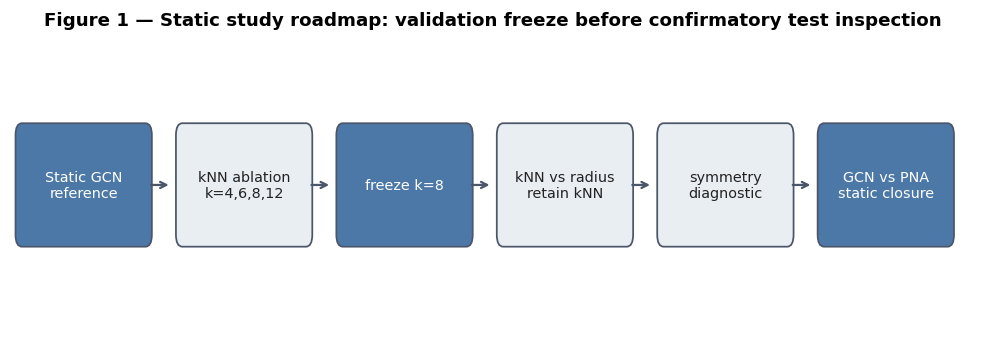

In [3]:
fig, ax = plt.subplots(figsize=(10.8, 3.4))
ax.set_xlim(0, 6); ax.set_ylim(0, 1); ax.axis('off')
labels = [('Static GCN\nreference', .45), ('kNN ablation\nk=4,6,8,12', 1.45), ('freeze k=8', 2.45),
          ('kNN vs radius\nretain kNN', 3.45), ('symmetry\ndiagnostic', 4.45), ('GCN vs PNA\nstatic closure', 5.45)]
for i, (label, x) in enumerate(labels):
    color = COLORS['frozen'] if i in [0,2,5] else '#E9EEF3'
    txt = 'white' if i in [0,2,5] else '#222222'
    box = FancyBboxPatch((x-.39,.34),.78,.34,boxstyle='round,pad=0.035,rounding_size=0.04',
                         facecolor=color,edgecolor='#4C566A',linewidth=1.1)
    ax.add_patch(box); ax.text(x,.51,label,ha='center',va='center',color=txt,fontsize=9)
    if i < len(labels)-1: ax.annotate('',xy=(x+.55,.51),xytext=(x+.4,.51),arrowprops=dict(arrowstyle='->',lw=1.4,color='#4C566A'))
ax.set_title('Figure 1 — Static study roadmap: validation freeze before confirmatory test inspection', pad=8)
fig01 = savefig(fig, 'fig01_static_study_roadmap.png')

# 4 — kNN neighborhood-size ablation

**Research question.** Does changing $k$ materially improve Static GCN performance?

**Hypothesis and control.** If the original neighborhood size is the dominant limitation, a matched alternative should improve validation MAE consistently across seeds. Dataset, Top-N, features, split identities, architecture, optimizer protocol, and all other settings remained fixed; only $k\in\{4,6,8,12\}$ changed. The selection record classified the effect as **SEED_DEPENDENT** and retained $k=8$. Test results below are confirmatory only.

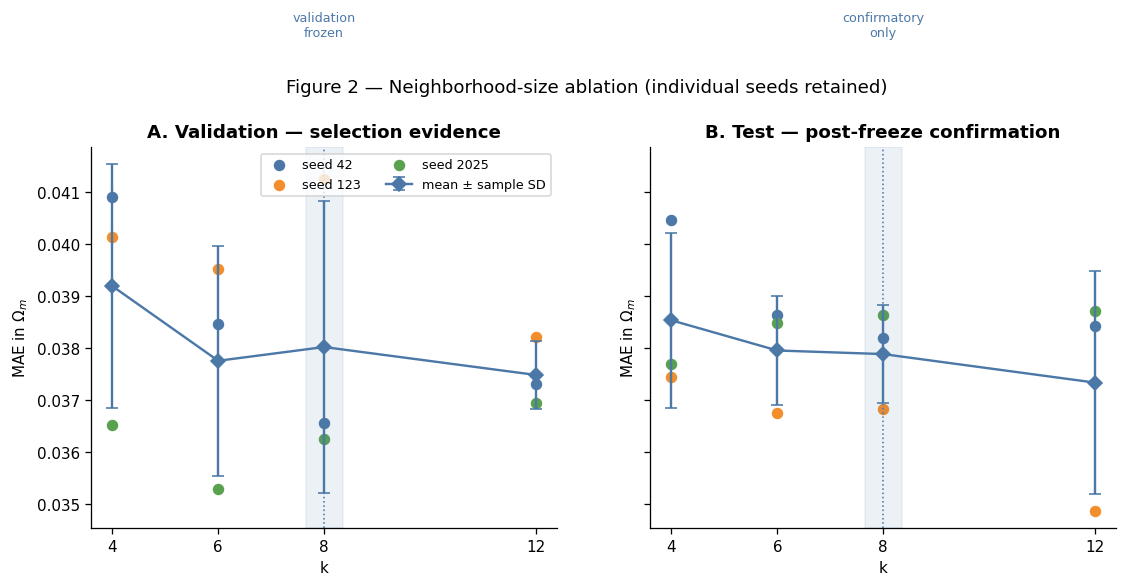

k,Validation MAE mean ± SD,Validation range,Test MAE mean ± SD,Test range,Conclusion
4,0.039196 ± 0.002343,0.036528–0.040920,0.038538 ± 0.001686,0.037443–0.040479,No robust advantage
6,0.037758 ± 0.002211,0.035281–0.039533,0.037956 ± 0.001048,0.036749–0.038636,No robust advantage
8,0.038023 ± 0.002815,0.036248–0.041268,0.037887 ± 0.000942,0.036829–0.038635,Frozen control
12,0.037485 ± 0.000655,0.036938–0.038211,0.037337 ± 0.002141,0.034871–0.038710,No robust advantage


In [4]:
knn_rows, knn_frames = [], {}
for k in KS:
    for seed in SEEDS:
        name = run_name('gcn', seed) if k == 8 else run_name('knn', seed, k)
        run = ROOT/'experiments'/name
        saved = load_json(run/'metrics.json')
        for split in ['val','test']:
            frame = pd.read_csv(run/f'predictions/{split}_predictions.csv')
            assert len(frame) == COUNTS[split] and frame.universe_id.is_unique
            assert set(frame.columns) == {'universe_id','true_omega_m','pred_omega_m','absolute_error','squared_error'}
            calc = metrics_from_predictions(frame)
            for metric in ['mae','rmse','r2']:
                assert math.isclose(calc[metric], saved[split][metric], rel_tol=0, abs_tol=1e-12)
            knn_frames[(k,seed,split)] = frame
            knn_rows.append({'k':k,'seed':seed,'split':split,**calc})
knn = pd.DataFrame(knn_rows)
assert len(knn) == 24 and sorted(knn.seed.unique()) == SEEDS

fig, axes = plt.subplots(1,2,figsize=(11.5,4.3),sharey=True)
for ax, split, title in zip(axes,['val','test'],['A. Validation — selection evidence','B. Test — post-freeze confirmation']):
    q = knn.query('split==@split')
    g = q.groupby('k').mae.agg(['mean','std'])
    ax.errorbar(g.index,g['mean'],yerr=g['std'],fmt='D-',color=COLORS['frozen'],capsize=4,label='mean ± sample SD')
    for seed in SEEDS:
        s=q.query('seed==@seed').sort_values('k'); ax.scatter(s.k,s.mae,s=38,color=SEED_COLORS[seed],label=f'seed {seed}')
    ax.axvspan(7.65,8.35,color=COLORS['frozen'],alpha=.10); ax.axvline(8,color=COLORS['frozen'],ls=':',lw=1)
    ax.set(title=title,xlabel='k',ylabel=r'MAE in $\Omega_m$',xticks=KS)
axes[0].legend(fontsize=8,ncol=2); axes[0].text(8,.0445,'validation\nfrozen',ha='center',va='top',fontsize=8,color=COLORS['frozen'])
axes[1].text(8,.0445,'confirmatory\nonly',ha='center',va='top',fontsize=8,color=COLORS['frozen'])
fig.suptitle('Figure 2 — Neighborhood-size ablation (individual seeds retained)',y=1.02)
fig02 = savefig(fig,'fig02_knn_k_ablation.png')

rows=[]
for k in KS:
    v=knn.query("k==@k and split=='val'").mae; t=knn.query("k==@k and split=='test'").mae
    rows.append([k,f'{v.mean():.6f} ± {v.std(ddof=1):.6f}',f'{v.min():.6f}–{v.max():.6f}',
                 f'{t.mean():.6f} ± {t.std(ddof=1):.6f}',f'{t.min():.6f}–{t.max():.6f}',
                 'Frozen control' if k==8 else 'No robust advantage'])
table02=pd.DataFrame(rows,columns=['k','Validation MAE mean ± SD','Validation range','Test MAE mean ± SD','Test range','Conclusion'])
save_table(table02,2,'knn_k_ablation'); display(table02.style.hide(axis='index'))

**Result and interpretation.** The validation winner changes with seed (seed 42: $k=8$; seed 123: $k=12$; seed 2025: $k=6$), while mean differences are small. Post-freeze test ranks also vary by seed. Thus no alternative $k$ establishes a robust advantage, and changing neighborhood size does not resolve range compression. **Conclusion: retain the predeclared $k=8$ control.**

# 5 — Graph-family test: kNN versus fixed radius

**Research question.** Is fixed-neighbor kNN connectivity itself responsible for the limitation?

The radius was calibrated from **training geometry only** to approximately match the aggregate unordered-edge budget of kNN($k=8$): $r^*=1.9628219604492188\ h^{-1}\mathrm{Mpc}$. Dataset, raw features, splits, Static GCN, and training protocol remained fixed. Matching an aggregate edge budget does not match local degree distributions, isolated-node behavior, or density sensitivity.

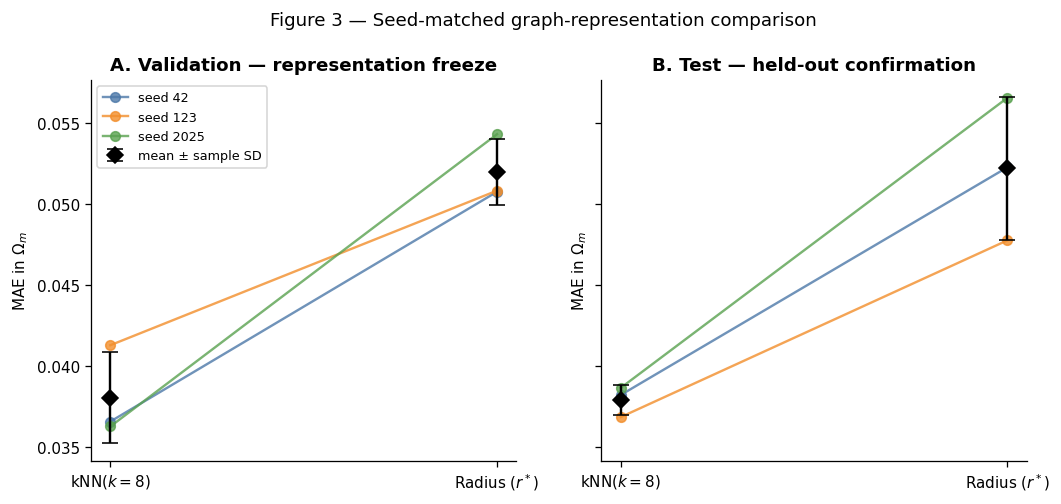

Representation,Validation MAE mean ± SD,Test MAE mean ± SD,Test R² mean ± SD,Test SD ratio,Test calibration slope,Conclusion
kNN(k=8),0.038023 ± 0.002815,0.037887 ± 0.000942,0.826323 ± 0.010566,0.870902,0.793589,Retained
Radius Static GCN,0.051953 ± 0.002032,0.052184 ± 0.004402,0.684284 ± 0.043254,0.791053,0.659925,ROBUST DEGRADATION


In [5]:
rep_rows, rep_frames = [], {}
for model, kind in [('kNN(k=8)','gcn'),('Radius','radius')]:
    for seed in SEEDS:
        run=ROOT/'experiments'/run_name(kind,seed); saved=load_json(run/'metrics.json')
        for split in ['val','test']:
            frame=pd.read_csv(run/f'predictions/{split}_predictions.csv'); assert len(frame)==COUNTS[split]
            calc=metrics_from_predictions(frame)
            for metric in ['mae','rmse','r2']: assert math.isclose(calc[metric],saved[split][metric],abs_tol=1e-12,rel_tol=0)
            rep_frames[(model,seed,split)]=frame; rep_rows.append({'representation':model,'seed':seed,'split':split,**calc})
rep=pd.DataFrame(rep_rows)
fig,axes=plt.subplots(1,2,figsize=(10.5,4.3),sharey=True)
for ax,split,title in zip(axes,['val','test'],['A. Validation — representation freeze','B. Test — held-out confirmation']):
    q=rep.query('split==@split')
    for seed in SEEDS:
        a=q.query("representation=='kNN(k=8)' and seed==@seed").mae.iloc[0]; b=q.query("representation=='Radius' and seed==@seed").mae.iloc[0]
        ax.plot([0,1],[a,b],'-o',color=SEED_COLORS[seed],alpha=.8,label=f'seed {seed}')
    for x,m in enumerate(['kNN(k=8)','Radius']):
        v=q.query('representation==@m').mae; ax.errorbar(x,v.mean(),yerr=v.std(ddof=1),fmt='D',ms=7,color='black',capsize=5,label='mean ± sample SD' if x==0 else None)
    ax.set_xticks([0,1],['kNN($k=8$)','Radius ($r^*$)']); ax.set(title=title,ylabel=r'MAE in $\Omega_m$')
axes[0].legend(fontsize=8); fig.suptitle('Figure 3 — Seed-matched graph-representation comparison',y=1.02)
fig03=savefig(fig,'fig03_knn_vs_radius.png')

rows=[]
for model,label in [('kNN(k=8)','kNN(k=8)'),('Radius','Radius Static GCN')]:
    v=rep.query("representation==@model and split=='val'"); t=rep.query("representation==@model and split=='test'")
    rows.append([label,f'{v.mae.mean():.6f} ± {v.mae.std(ddof=1):.6f}',f'{t.mae.mean():.6f} ± {t.mae.std(ddof=1):.6f}',
                 f'{t.r2.mean():.6f} ± {t.r2.std(ddof=1):.6f}',f'{t.sd_ratio.mean():.6f}',f'{t.slope.mean():.6f}',
                 'Retained' if model.startswith('kNN') else 'ROBUST DEGRADATION'])
table03=pd.DataFrame(rows,columns=['Representation','Validation MAE mean ± SD','Test MAE mean ± SD','Test R² mean ± SD','Test SD ratio','Test calibration slope','Conclusion'])
save_table(table03,3,'graph_family_comparison'); display(table03.style.hide(axis='index'))

**Result.** Radius increases MAE in all three seed-matched validation comparisons, establishing **ROBUST DEGRADATION** before test inspection; held-out test behavior repeats the direction. It also reduces $R^2$, prediction dispersion, and calibration slope. **Conclusion:** the tested calibrated radius representation does not solve the Static GCN limitation. This is specific to this radius construction and is not a universal claim that radius graphs are inferior.

# 6 — Symmetry diagnostic

**Research question.** Does the frozen Static GCN give invariant predictions under physically equivalent transformations?

Four periodic translations transform XYZ modulo the $25\ h^{-1}\mathrm{Mpc}$ box. The 24 proper cube rotations transform positions and velocity vectors together; the identity rotation is retained as a numerical control and excluded from non-identity summaries. Frozen periodic kNN edges were reused, so graph topology remained unchanged. The preregistered tolerance is $10^{-6}+10^{-5}|\hat y|$.

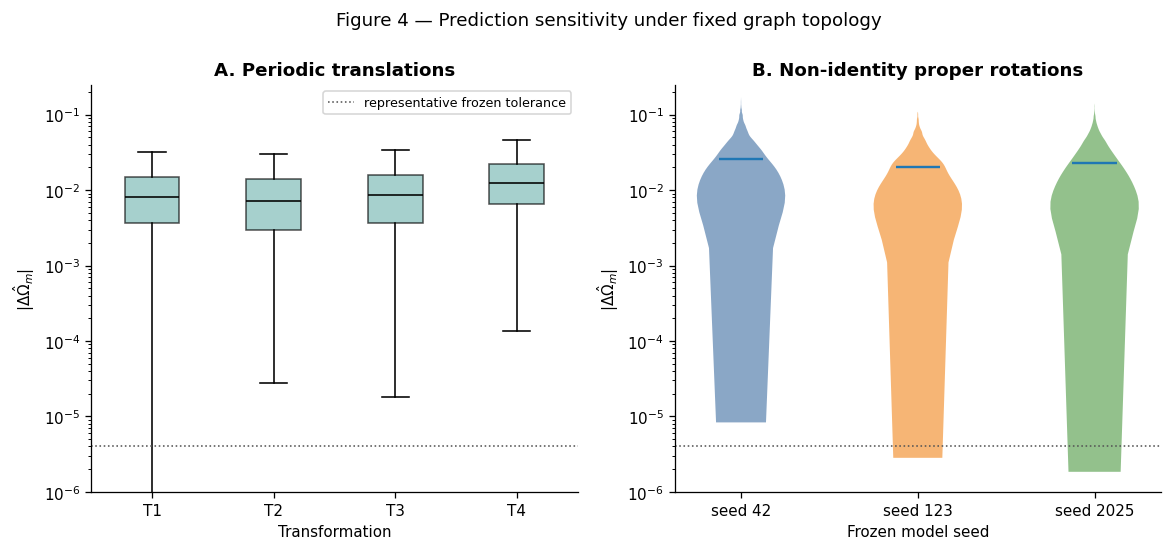

Seed,Translation mean |Δ|,Translation RMS,Translation max,Translation failure fraction,Rotation mean |Δ|,Rotation RMS,Rotation max,Rotation failure fraction
42,0.013147,0.018023,0.097350,1.000000,0.026057,0.035240,0.167753,1.000000
123,0.011086,0.015421,0.089058,1.000000,0.020306,0.027135,0.108550,1.000000
2025,0.012071,0.016486,0.073789,0.998756,0.022750,0.030574,0.139047,0.999784


In [6]:
sym=pd.read_csv(sym_pred_path)
assert len(sym)==16884 and sorted(sym.seed.unique())==SEEDS
assert not sym.duplicated(['seed','universe_id','transform_family','transform_id']).any()
identity=sym.query("transform_family=='rotation' and transform_id=='R03'")
assert len(identity)==603 and (identity.absolute_delta==0).all() and not identity.tolerance_failure.any()
translations=sym.query("transform_family=='translation'").copy()
rotations=sym.query("transform_family=='rotation' and transform_id!='R03'").copy()
assert len(translations)==2412 and len(rotations)==13869

fig,axes=plt.subplots(1,2,figsize=(12,4.6))
td=[translations.query('transform_id==@tid').absolute_delta.to_numpy() for tid in ['T1','T2','T3','T4']]
b=axes[0].boxplot(td,tick_labels=['T1','T2','T3','T4'],showfliers=False,patch_artist=True,
                  medianprops=dict(color='black'),boxprops=dict(facecolor=COLORS['Static GCN'],alpha=.65))
axes[0].set(title='A. Periodic translations',xlabel='Transformation',ylabel=r'$|\Delta\hat\Omega_m|$')
rd=[rotations.query('seed==@seed').absolute_delta.to_numpy() for seed in SEEDS]
v=axes[1].violinplot(rd,positions=range(3),showmeans=True,showextrema=False)
for body,c in zip(v['bodies'],[SEED_COLORS[s] for s in SEEDS]): body.set_facecolor(c); body.set_alpha(.65)
axes[1].set_xticks(range(3),[f'seed {s}' for s in SEEDS]); axes[1].set(title='B. Non-identity proper rotations',xlabel='Frozen model seed',ylabel=r'$|\Delta\hat\Omega_m|$')
for ax in axes:
    ax.set_yscale('log'); ax.set_ylim(1e-6, 2.5e-1); ax.axhline(4e-6,color='#555555',ls=':',lw=1,label='representative frozen tolerance')
axes[0].legend(fontsize=8); fig.suptitle('Figure 4 — Prediction sensitivity under fixed graph topology',y=1.02)
fig04=savefig(fig,'fig04_symmetry_diagnostic.png')

sym_rows=[]
for seed in SEEDS:
    row=[seed]
    for q in [translations.query('seed==@seed'),rotations.query('seed==@seed')]:
        row += [q.absolute_delta.mean(),math.sqrt(np.mean(q.signed_delta.to_numpy()**2)),q.absolute_delta.max(),q.tolerance_failure.mean()]
    sym_rows.append(row)
table_sym=pd.DataFrame(sym_rows,columns=['Seed','Translation mean |Δ|','Translation RMS','Translation max','Translation failure fraction',
                                        'Rotation mean |Δ|','Rotation RMS','Rotation max','Rotation failure fraction'])
for c in table_sym.columns[1:]: table_sym[c]=table_sym[c].map(lambda x:f'{x:.6f}')
display(table_sym.style.hide(axis='index'))

**Result: SUBSTANTIAL SYSTEMATIC VIOLATION.** Repeated identity inference and the identity rotation have an exactly zero numerical floor, yet nearly every non-identity transformation exceeds tolerance. Because topology was invariant, the diagnostic demonstrates genuine sensitivity of the trained model to transformed raw features. It proves lack of invariance; it does **not** prove that symmetry sensitivity causes prediction compression.

# 7 — Static GCN versus Static PNA

**Research question.** Does a stronger static graph operator improve $\Omega_m$ prediction?

PNA combines mean, min, max, and standard-deviation aggregators with identity, amplification, and attenuation scalers. Data, graph, splits, width, depth, pooling, head, and optimization settings remain matched. GCN has 5,281 parameters and PNA 51,553 (9.76×). This is therefore a **controlled architecture benchmark**, not a parameter-count-matched operator ablation.

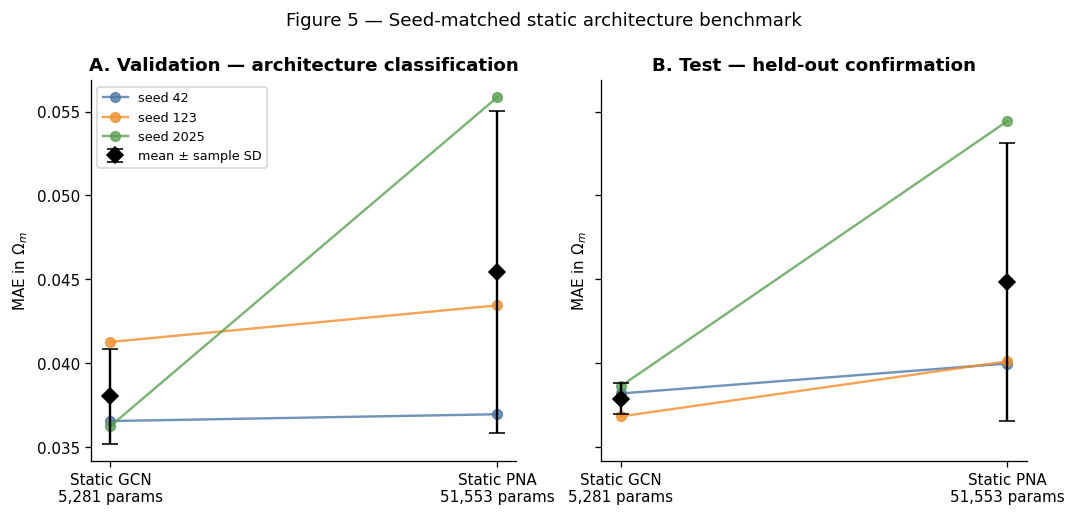

Model,Parameters,Validation MAE mean ± SD,Test MAE mean ± SD,Test RMSE mean ± SD,Test R² mean ± SD,Test SD ratio,Test calibration slope
Static GCN,"5,281",0.038023 ± 0.002815,0.037887 ± 0.000942,0.049348 ± 0.000624,0.826323 ± 0.010566,0.870902,0.793589
Static PNA,"51,553",0.045415 ± 0.009593,0.044845 ± 0.008305,0.056757 ± 0.010753,0.766313 ± 0.084636,0.745575,0.682671


In [7]:
arch_rows, arch_frames = [], {}
for model,kind in [('Static GCN','gcn'),('Static PNA','pna')]:
    for seed in SEEDS:
        run=ROOT/'experiments'/run_name(kind,seed); saved=load_json(run/'metrics.json')
        assert saved['trainable_parameters']==({'Static GCN':5281,'Static PNA':51553}[model])
        for split in ['val','test']:
            frame=pd.read_csv(run/f'predictions/{split}_predictions.csv'); assert len(frame)==COUNTS[split]
            calc=metrics_from_predictions(frame)
            for metric in ['mae','rmse','r2']: assert math.isclose(calc[metric],saved[split][metric],abs_tol=1e-12,rel_tol=0)
            arch_frames[(model,seed,split)]=frame; arch_rows.append({'model':model,'seed':seed,'split':split,**calc})
arch=pd.DataFrame(arch_rows)
fig,axes=plt.subplots(1,2,figsize=(10.5,4.3),sharey=True)
for ax,split,title in zip(axes,['val','test'],['A. Validation — architecture classification','B. Test — held-out confirmation']):
    q=arch.query('split==@split')
    for seed in SEEDS:
        a=q.query("model=='Static GCN' and seed==@seed").mae.iloc[0]; b=q.query("model=='Static PNA' and seed==@seed").mae.iloc[0]
        ax.plot([0,1],[a,b],'-o',color=SEED_COLORS[seed],alpha=.8,label=f'seed {seed}')
    for x,m in enumerate(['Static GCN','Static PNA']):
        v=q.query('model==@m').mae; ax.errorbar(x,v.mean(),yerr=v.std(ddof=1),fmt='D',ms=7,color='black',capsize=5,label='mean ± sample SD' if x==0 else None)
    ax.set_xticks([0,1],['Static GCN\n5,281 params','Static PNA\n51,553 params']); ax.set(title=title,ylabel=r'MAE in $\Omega_m$')
axes[0].legend(fontsize=8); fig.suptitle('Figure 5 — Seed-matched static architecture benchmark',y=1.02)
fig05=savefig(fig,'fig05_gcn_vs_pna.png')

rows=[]
for model,params in [('Static GCN',5281),('Static PNA',51553)]:
    v=arch.query("model==@model and split=='val'"); t=arch.query("model==@model and split=='test'")
    rows.append([model,f'{params:,}',f'{v.mae.mean():.6f} ± {v.mae.std(ddof=1):.6f}',f'{t.mae.mean():.6f} ± {t.mae.std(ddof=1):.6f}',
                 f'{t.rmse.mean():.6f} ± {t.rmse.std(ddof=1):.6f}',f'{t.r2.mean():.6f} ± {t.r2.std(ddof=1):.6f}',
                 f'{t.sd_ratio.mean():.6f}',f'{t.slope.mean():.6f}'])
table04=pd.DataFrame(rows,columns=['Model','Parameters','Validation MAE mean ± SD','Test MAE mean ± SD','Test RMSE mean ± SD','Test R² mean ± SD','Test SD ratio','Test calibration slope'])
save_table(table04,4,'gcn_vs_pna'); display(table04.style.hide(axis='index'))
assert all(arch.query("model=='Static PNA' and split=='test'").set_index('seed').mae > arch.query("model=='Static GCN' and split=='test'").set_index('seed').mae)

**Result.** PNA has higher validation MAE in every matched seed, yielding the frozen classification **ROBUST DEGRADATION**. Held-out test MAE is also higher in every seed. Under this matched regime, greater PNA complexity did not establish an advantage; because parameter counts differ, the result does not isolate the aggregation operator as a causal factor.

# 8 — True versus predicted $\Omega_m$

This core parity figure retains each seed-specific test partition as a separate panel. Common limits, equal aspect, the ideal $y=x$ relation, and per-panel calibration fits make prediction-range compression directly comparable without treating the three split realizations as one independent sample.

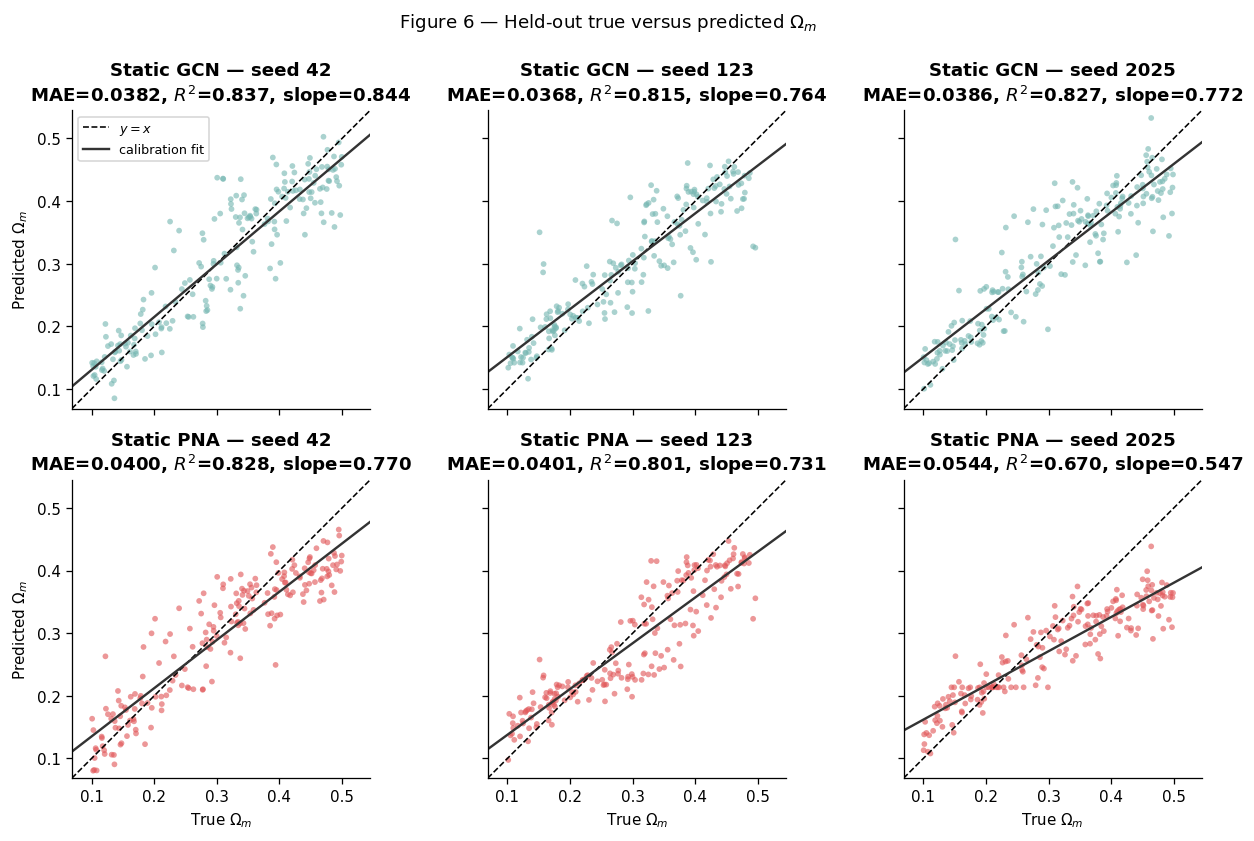

In [8]:
all_values=np.concatenate([f[['true_omega_m','pred_omega_m']].to_numpy().ravel() for (m,s,sp),f in arch_frames.items() if sp=='test'])
lo,hi=float(all_values.min()-.012),float(all_values.max()+.012)
fig,axes=plt.subplots(2,3,figsize=(11.5,7.3),sharex=True,sharey=True)
for i,model in enumerate(['Static GCN','Static PNA']):
    for j,seed in enumerate(SEEDS):
        ax=axes[i,j]; f=arch_frames[(model,seed,'test')]; d=arch.query('model==@model and seed==@seed and split=="test"').iloc[0]
        ax.scatter(f.true_omega_m,f.pred_omega_m,s=13,alpha=.62,color=COLORS[model],edgecolors='none')
        xx=np.array([lo,hi]); ax.plot(xx,xx,'k--',lw=1,label='$y=x$'); ax.plot(xx,d.intercept+d.slope*xx,color='#333333',lw=1.5,label='calibration fit')
        ax.set(xlim=(lo,hi),ylim=(lo,hi),aspect='equal',title=f'{model} — seed {seed}\nMAE={d.mae:.4f}, $R^2$={d.r2:.3f}, slope={d.slope:.3f}')
        if i==1: ax.set_xlabel(r'True $\Omega_m$')
        if j==0: ax.set_ylabel(r'Predicted $\Omega_m$')
axes[0,0].legend(fontsize=8,loc='upper left'); fig.suptitle(r'Figure 6 — Held-out true versus predicted $\Omega_m$',y=.995)
fig.tight_layout(); fig06=savefig(fig,'fig06_true_vs_predicted.png')

**Interpretation.** Both architectures follow the target ordering, but fitted slopes remain below one: low targets tend to be predicted too high and high targets too low. PNA seed 2025 shows the strongest narrowing. Separate panels preserve the fact that each model seed has its own held-out partition.

# 9 — Residual analysis

Residuals are defined as $\hat\Omega_m-\Omega_m$. Raw points are retained, while equal-width binned means summarize direction without a smoothing model.

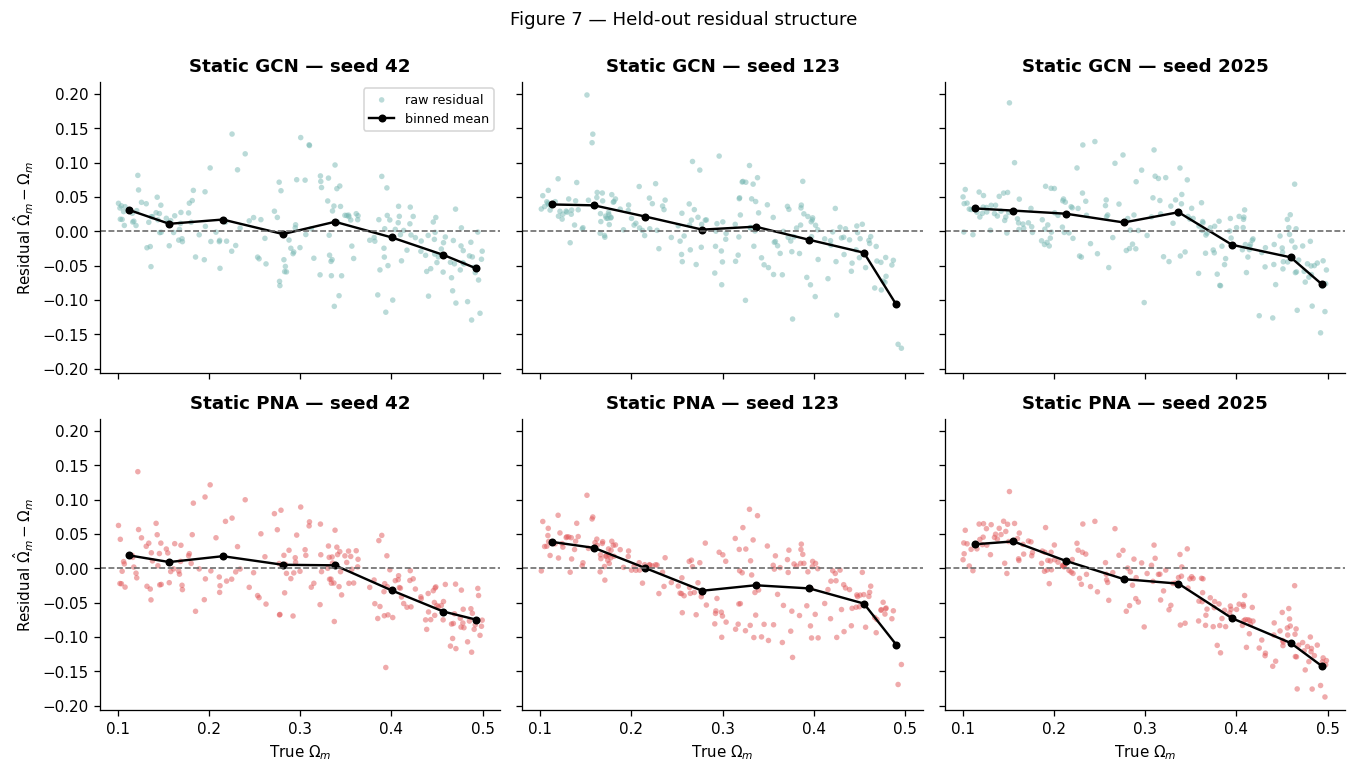

In [9]:
fig,axes=plt.subplots(2,3,figsize=(11.8,6.7),sharex=True,sharey=True)
bins=np.linspace(lo,hi,9)
for i,model in enumerate(['Static GCN','Static PNA']):
    for j,seed in enumerate(SEEDS):
        ax=axes[i,j]; f=arch_frames[(model,seed,'test')].copy(); f['residual']=f.pred_omega_m-f.true_omega_m
        ax.scatter(f.true_omega_m,f.residual,s=12,alpha=.5,color=COLORS[model],edgecolors='none',label='raw residual')
        f['bin']=pd.cut(f.true_omega_m,bins,include_lowest=True); bg=f.groupby('bin',observed=True).agg(x=('true_omega_m','mean'),r=('residual','mean')).dropna()
        ax.plot(bg.x,bg.r,'o-',color='black',lw=1.5,ms=4,label='binned mean'); ax.axhline(0,color='#666666',ls='--',lw=1)
        ax.set(title=f'{model} — seed {seed}');
        if i==1: ax.set_xlabel(r'True $\Omega_m$')
        if j==0: ax.set_ylabel(r'Residual $\hat\Omega_m-\Omega_m$')
axes[0,0].legend(fontsize=8); fig.suptitle('Figure 7 — Held-out residual structure',y=.995)
fig.tight_layout(); fig07=savefig(fig,'fig07_residuals.png')

**Interpretation.** The binned curves expose a common regression-to-the-mean pattern: positive residuals dominate the low-target regime and negative residuals dominate the high-target regime. This structure is consistent with prediction compression and is generally stronger for PNA, especially in seed 2025.

# 10 — Prediction range and calibration

Two complementary quantities test compression: prediction SD divided by target SD, and the slope from the ordinary least-squares calibration relation $\hat y=a+b y$. Both have ideal value 1.

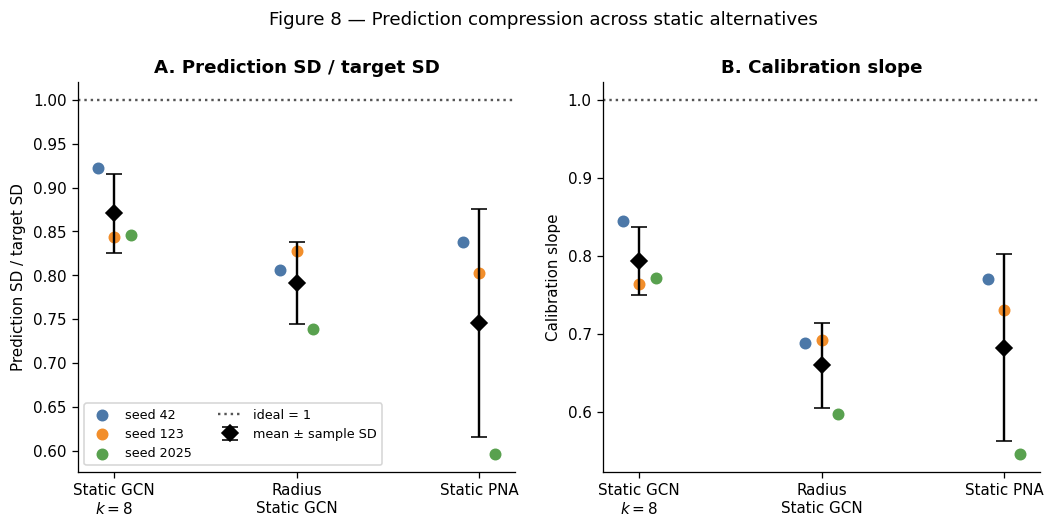

In [10]:
compression=pd.concat([
    rep.query("representation=='kNN(k=8)' and split=='test'").assign(configuration='Static GCN k=8'),
    rep.query("representation=='Radius' and split=='test'").assign(configuration='Radius Static GCN'),
    arch.query("model=='Static PNA' and split=='test'").assign(configuration='Static PNA')
],ignore_index=True)
configs=['Static GCN k=8','Radius Static GCN','Static PNA']
fig,axes=plt.subplots(1,2,figsize=(10.8,4.4))
for ax,metric,label in zip(axes,['sd_ratio','slope'],['Prediction SD / target SD','Calibration slope']):
    for x,cfg in enumerate(configs):
        q=compression.query('configuration==@cfg'); color=COLORS['Static GCN' if cfg.startswith('Static GCN') else cfg]
        for seed,jitter in zip(SEEDS,[-.09,0,.09]): ax.scatter(x+jitter,q.query('seed==@seed')[metric],s=42,color=SEED_COLORS[seed],zorder=3,label=f'seed {seed}' if x==0 else None)
        ax.errorbar(x,q[metric].mean(),yerr=q[metric].std(ddof=1),fmt='D',ms=7,color='black',capsize=5,zorder=4,label='mean ± sample SD' if x==0 else None)
    ax.axhline(1,color='#555555',ls=':',label='ideal = 1'); ax.set_xticks(range(3),['Static GCN\n$k=8$','Radius\nStatic GCN','Static PNA']); ax.set(ylabel=label,title=f'{"A" if metric=="sd_ratio" else "B"}. {label}')
axes[0].legend(fontsize=8,ncol=2); fig.suptitle('Figure 8 — Prediction compression across static alternatives',y=1.02)
fig08=savefig(fig,'fig08_prediction_compression.png')

**Result.** Every seed-level SD ratio and calibration slope is below one. The mean SD ratio changes from 0.870902 (GCN) to 0.791053 (radius) and 0.745575 (PNA); mean slopes change from 0.793589 to 0.659925 and 0.682671. Compression therefore persists across all tested static alternatives and worsens under both treatments relative to the frozen GCN.

# 11 — Training-curve diagnostic decision

Existing logs were inspected during the frozen architecture evaluation. Although PNA seed 2025 has a notably larger error, training curves would show optimization trajectories rather than identify a unique mechanism. Because they do not support a defensible causal label such as overfitting, underfitting, or optimization failure, an additional training-curve figure is omitted. No new training is performed.

# 12 — Final hypothesis summary

The table distinguishes what each controlled experiment can reject from mechanisms that remain unresolved.

In [11]:
table05=pd.DataFrame([
 ['Wrong k causes the limitation','k = 4, 6, 8, 12','Small effects; seed-specific winners','Not supported / seed-dependent'],
 ['kNN graph family causes the limitation','kNN(k=8) vs calibrated radius','Radius raises validation and test MAE in every seed','Not supported for tested radius representation'],
 ['Model respects box symmetries','Periodic translations + proper cube rotations','Near-universal tolerance failure at zero identity floor','Rejected'],
 ['Simple GCN message passing is the main limitation','Static GCN vs Static PNA','Larger PNA raises validation and test MAE in every seed','Not supported by tested PNA benchmark'],
 ['Prediction compression remains','SD ratio and calibration slope','All seed-level values remain below 1','Supported'],
],columns=['Hypothesis','Controlled experiment','Main evidence','Conclusion'])
save_table(table05,5,'hypothesis_summary'); display(table05.style.hide(axis='index'))

Hypothesis,Controlled experiment,Main evidence,Conclusion
Wrong k causes the limitation,"k = 4, 6, 8, 12",Small effects; seed-specific winners,Not supported / seed-dependent
kNN graph family causes the limitation,kNN(k=8) vs calibrated radius,Radius raises validation and test MAE in every seed,Not supported for tested radius representation
Model respects box symmetries,Periodic translations + proper cube rotations,Near-universal tolerance failure at zero identity floor,Rejected
Simple GCN message passing is the main limitation,Static GCN vs Static PNA,Larger PNA raises validation and test MAE in every seed,Not supported by tested PNA benchmark
Prediction compression remains,SD ratio and calibration slope,All seed-level values remain below 1,Supported


# 13 — Final static-model summary

This table reports the principal matched static alternatives. Neighborhood-size variants remain an ablation (Table 2) rather than being mixed into the final model comparison.

In [12]:
summary_rows=[]
for label,source,params,conclusion in [
    ('Static GCN k=8',rep.query("representation=='kNN(k=8)'"),5281,'Frozen static reference'),
    ('Radius Static GCN',rep.query("representation=='Radius'"),5281,'Robust degradation'),
    ('Static PNA',arch.query("model=='Static PNA'"),51553,'Robust degradation')]:
    v=source.query("split=='val'"); t=source.query("split=='test'")
    summary_rows.append([label,f'{params:,}',f'{v.mae.mean():.6f} ± {v.mae.std(ddof=1):.6f}',f'{t.mae.mean():.6f} ± {t.mae.std(ddof=1):.6f}',
                         f'{t.rmse.mean():.6f} ± {t.rmse.std(ddof=1):.6f}',f'{t.r2.mean():.6f} ± {t.r2.std(ddof=1):.6f}',
                         f'{t.sd_ratio.mean():.6f}',f'{t.slope.mean():.6f}',conclusion])
table06=pd.DataFrame(summary_rows,columns=['Representation / model','Parameters','Validation MAE mean ± SD','Test MAE mean ± SD','Test RMSE mean ± SD','Test R² mean ± SD','Test SD ratio','Test slope','Key conclusion'])
save_table(table06,6,'final_static_model_summary'); display(table06.style.hide(axis='index'))

Representation / model,Parameters,Validation MAE mean ± SD,Test MAE mean ± SD,Test RMSE mean ± SD,Test R² mean ± SD,Test SD ratio,Test slope,Key conclusion
Static GCN k=8,"5,281",0.038023 ± 0.002815,0.037887 ± 0.000942,0.049348 ± 0.000624,0.826323 ± 0.010566,0.870902,0.793589,Frozen static reference
Radius Static GCN,"5,281",0.051953 ± 0.002032,0.052184 ± 0.004402,0.066516 ± 0.005429,0.684284 ± 0.043254,0.791053,0.659925,Robust degradation
Static PNA,"51,553",0.045415 ± 0.009593,0.044845 ± 0.008305,0.056757 ± 0.010753,0.766313 ± 0.084636,0.745575,0.682671,Robust degradation


# 14 — Scientific conclusions

Changing $k$ does not yield a seed-robust improvement, and replacing kNN with the tested training-calibrated radius graph substantially degrades accuracy and compression metrics. The frozen Static GCN is demonstrably non-invariant to physically equivalent periodic translations and proper cube rotations under fixed topology. Yet replacing GCN message passing with a roughly 9.76× larger PNA also fails to improve validation or held-out test MAE and worsens prediction dispersion and calibration.

Together, these controlled negative results weaken several plausible explanations: neither a locally mistuned $k$, the tested fixed-radius alternative, nor static architectural complexity alone resolves the limitation. Prediction-range compression remains unresolved. Symmetry sensitivity is a concrete representation/model defect, but this diagnostic does not establish that it causes compression. Eliminating these explanations is scientifically useful because it narrows the space of credible next hypotheses without rewriting the evidence as a positive result.

# 15 — Limitations

- Across-seed summaries use only three seeds and are descriptive mean ± sample SD, not inferential uncertainty.
- PNA is not parameter-count matched to GCN, and only one canonical PNA configuration was tested without a hyperparameter sweep.
- Only one training-geometry-calibrated radius treatment was tested; conclusions do not generalize to all radius graphs.
- The symmetry diagnostic establishes non-invariance, not causal impact on MAE or compression.
- Raw absolute coordinates remain a potential representation issue.
- Static models omit temporal evolution.
- Conclusions apply to CAMELS-SIMBA U1000 / Top1500 / raw7 / final-snapshot / unnormalized inputs in the stated graph regime.
- Summary-feature baselines are intentionally not placed in the final controlled table; cross-representation baseline context is handled in Notebook 13 and requires its own framing.

# 16 — Reproducibility closure and transition

The final cell rechecks row counts, seed coverage, figure/table completeness, and the principal frozen numerical values. It also verifies that PNA remains worse on test MAE for all three matched seeds.

In [13]:
expected={'GCN validation MAE':0.038022502704902934,'PNA validation MAE':0.04541493861964255,
          'GCN test MAE':0.03788663609127972,'PNA test MAE':0.04484481735677361,
          'Radius test MAE':0.05218388678741761}
observed={'GCN validation MAE':arch.query("model=='Static GCN' and split=='val'").mae.mean(),
          'PNA validation MAE':arch.query("model=='Static PNA' and split=='val'").mae.mean(),
          'GCN test MAE':arch.query("model=='Static GCN' and split=='test'").mae.mean(),
          'PNA test MAE':arch.query("model=='Static PNA' and split=='test'").mae.mean(),
          'Radius test MAE':rep.query("representation=='Radius' and split=='test'").mae.mean()}
audit=[]
for key in expected:
    delta=observed[key]-expected[key]; assert abs(delta)<5e-7
    audit.append([key,observed[key],expected[key],delta,'PASS'])
audit=pd.DataFrame(audit,columns=['Quantity','Notebook-derived','Frozen reference','Difference','Status'])
display(audit.style.format({'Notebook-derived':'{:.9f}','Frozen reference':'{:.9f}','Difference':'{:+.2e}'}).hide(axis='index'))

assert set(knn.groupby(['k','split']).size())=={3}
assert set(rep.groupby(['representation','split']).size())=={3}
assert set(arch.groupby(['model','split']).size())=={3}
assert all(len(f)==COUNTS[sp] for (k,s,sp),f in knn_frames.items())
assert all(len(f)==COUNTS[sp] for (m,s,sp),f in arch_frames.items())
assert all(arch.query("model=='Static PNA' and split=='test'").set_index('seed').mae > arch.query("model=='Static GCN' and split=='test'").set_index('seed').mae)
figures=sorted(OUT.glob('fig*.png')); tables=sorted(OUT.glob('table*.csv'))
assert len(figures)==8 and all(p.stat().st_size>0 for p in figures)
assert len(tables)==6 and all(p.stat().st_size>0 and len(pd.read_csv(p))>0 for p in tables)
closure=pd.DataFrame([
 ['Critical artifacts','PASS',f'{len(registry_files)} registry/report sources; {len(required_runs)} runs'],
 ['Prediction rows','PASS','99 validation and 201 test rows per loaded run'],
 ['Seed coverage','PASS','42, 123, 2025 in every comparison'],
 ['Frozen-result consistency','PASS','5/5 principal mean-MAE checks'],
 ['PNA matched-seed direction','PASS','worse test MAE in 3/3 seeds'],
 ['Figures / tables','PASS',f'{len(figures)} figures / {len(tables)} tables'],
 ['Training or inference','NO','stored artifacts only'],
],columns=['Closure item','Status','Evidence'])
display(closure.style.hide(axis='index'))
print('NOTEBOOK 15 STATIC STUDY CLOSED — READY FOR REVIEW')

Quantity,Notebook-derived,Frozen reference,Difference,Status
GCN validation MAE,0.038022503,0.038022503,+0.00e+00,PASS
PNA validation MAE,0.045414939,0.045414939,+6.94e-18,PASS
GCN test MAE,0.037886619,0.037886636,-1.66e-08,PASS
PNA test MAE,0.044844686,0.044844817,-1.31e-07,PASS
Radius test MAE,0.052184209,0.052183887,+3.22e-07,PASS


Closure item,Status,Evidence
Critical artifacts,PASS,10 registry/report sources; 18 runs
Prediction rows,PASS,99 validation and 201 test rows per loaded run
Seed coverage,PASS,"42, 123, 2025 in every comparison"
Frozen-result consistency,PASS,5/5 principal mean-MAE checks
PNA matched-seed direction,PASS,worse test MAE in 3/3 seeds
Figures / tables,PASS,8 figures / 6 tables
Training or inference,NO,stored artifacts only


NOTEBOOK 15 STATIC STUDY CLOSED — READY FOR REVIEW


## Transition to Notebook 16

**Static study CLOSED.** Static graph construction and static message-passing complexity have now been systematically investigated. The next research question is whether explicit information across snapshots improves $\Omega_m$ regression. A later Notebook 16 may compare existing EvolveGCN-H, GCN–GRU, and GCN–Temporal-Transformer approaches; **that temporal study is not started here.**